In [ ]:
from google.colab import files

uploaded=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.size

147903

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.columns=df.columns.str.lower()

In [ ]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [ ]:
df.drop('customerid',axis=1,inplace=True)

In [ ]:
df.drop('seniorcitizen',axis=1,inplace=True)

In [ ]:
df.head()

,gender,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# how many customer left vs stayed

df['churn'].value_counts()

,count
churn,
No,5174
Yes,1869


In [ ]:
#  percentage of customer left or stay

df['churn'].value_counts(normalize=True)

,proportion
churn,
No,0.73463
Yes,0.26537


In [ ]:
# avg tenure of who left

df[df['churn']=='Yes'].tenure.mean()

np.float64(17.979133226324237)

In [ ]:
# monthly charges based on churn

monthly_charge=df.groupby(['churn'])['monthlycharges'].mean()
monthly_charge


,monthlycharges
churn,
No,61.265124
Yes,74.441332


In [ ]:
# monthly charges on tenure

monthly_charge_tenure=df.groupby(['tenure'])['monthlycharges'].mean()
monthly_charge_tenure

,monthlycharges
tenure,
0,41.418182
1,50.485808
2,57.206303
3,58.015000
4,57.432670
...,...
68,73.321000
69,70.823158
70,76.378992


<Axes: xlabel='churn', ylabel='count'>

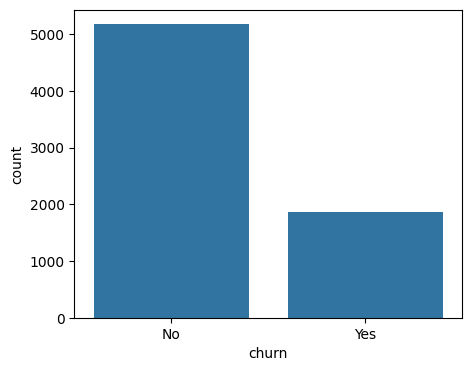

In [ ]:
# graph of target distribution

plt.figure(figsize=(5,4))
sns.countplot(x='churn',data=df)

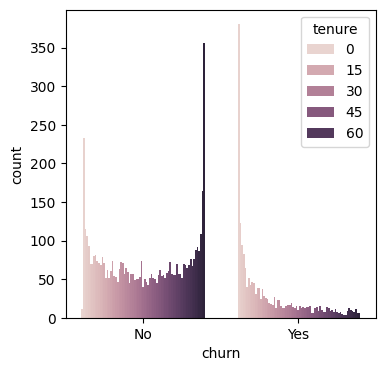

In [ ]:
# churn based on tenure

plt.figure(figsize=(4,4))
sns.countplot(x='churn', hue='tenure', data=df)
plt.show()

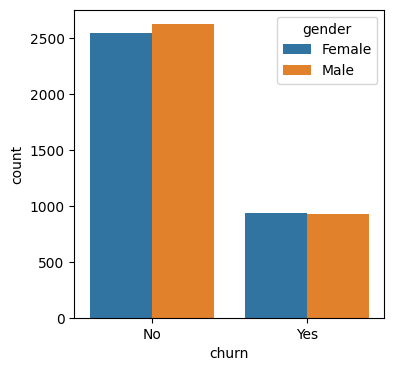

In [ ]:
# churn based on gender

plt.figure(figsize=(4,4))
sns.countplot(x='churn', hue='gender', data=df)
plt.show()

In [ ]:
df['churn']=df['churn'].map({'Yes':1,'No':0})

In [ ]:
df['churn'].unique()

array([0, 1])

In [ ]:
df['gender']=df['gender'].map({'Female':1,'Male':0})

In [ ]:
df['gender'].unique()

array([1, 0])

In [ ]:
df['dependents']=df['dependents'].map({'Yes':1,'No':0})

In [ ]:
df['phoneservice']=df['phoneservice'].map({'Yes':1,'No':0})

In [ ]:
df['paperlessbilling']=df['paperlessbilling'].map({'Yes':1,'No':0})

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.head()

,gender,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,churn,partner_Yes,multiplelines_No phone service,multiplelines_Yes,...,totalcharges_995.35,totalcharges_996.45,totalcharges_996.85,totalcharges_996.95,totalcharges_997.65,totalcharges_997.75,totalcharges_998.1,totalcharges_999.45,totalcharges_999.8,totalcharges_999.9
0,1,0,1,0,1,29.85,0,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0,34,1,0,56.95,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,0,2,1,1,53.85,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,0,45,0,0,42.30,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,0,2,1,1,70.70,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df['churn'].unique()

array([0, 1])

In [ ]:
# feature and target seperation
x=df.drop('churn',axis=1)
y=df['churn']

In [ ]:
x.columns

Index(['gender', 'dependents', 'tenure', 'phoneservice', 'paperlessbilling',
       'monthlycharges', 'partner_Yes', 'multiplelines_No phone service',
       'multiplelines_Yes', 'internetservice_Fiber optic',
       ...
       'totalcharges_995.35', 'totalcharges_996.45', 'totalcharges_996.85',
       'totalcharges_996.95', 'totalcharges_997.65', 'totalcharges_997.75',
       'totalcharges_998.1', 'totalcharges_999.45', 'totalcharges_999.8',
       'totalcharges_999.9'],
      dtype='object', length=6558)

In [ ]:
# train and test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
churn,
0,0.734647
1,0.265353


In [ ]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.73463
1,0.26537


In [ ]:
# scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
# imlementing the model

# logistic regression

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# predicting

y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [ ]:
# accuracy

from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

0.9900603478878239
0.7757274662881476


In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_train,y_pred_train))
print(confusion_matrix(y_test,y_pred_test))

[[4112   27]
 [  29 1466]]
[[905 130]
 [186 188]]


In [ ]:
# classification report

from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred_train))
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4139
           1       0.98      0.98      0.98      1495

    accuracy                           0.99      5634
   macro avg       0.99      0.99      0.99      5634
weighted avg       0.99      0.99      0.99      5634

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
# predicting
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [ ]:
# evluation

print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))


0.997515086971956
0.7629524485450674


In [ ]:
# confusion matrix

cm=confusion_matrix(y_test,y_pred_test)
cm

array([[888, 147],
       [187, 187]])

In [ ]:
# classification report
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1035
           1       0.56      0.50      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.76      0.76      0.76      1409



In [ ]:
# random forest

from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(n_estimators=10,random_state=42)
model_rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [ ]:
# predicting

y_pred_train=model_rf.predict(x_train)
y_pred_test=model_rf.predict(x_test)

In [ ]:
# accuracy

print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

0.9787007454739084
0.7757274662881476


In [ ]:
# confusion matrix

cm=confusion_matrix(y_test,y_pred_test)
cm

array([[937,  98],
       [218, 156]])

In [ ]:
# classication report

print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1035
           1       0.61      0.42      0.50       374

    accuracy                           0.78      1409
   macro avg       0.71      0.66      0.68      1409
weighted avg       0.76      0.78      0.76      1409

